In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [12]:
aqi = pd.read_csv("city_day.csv")
crop = pd.read_csv("crop_production.csv")

print(aqi.head())
print(crop.head())

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicobar Islands      NICOBARS 

DATA PROFILING AND INITIAL INSPECTION

In [13]:
print("\nCrop Dataset Info")
print(crop.info())

print("\nAQI Dataset Info")
print(aqi.info())


Crop Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB
None

AQI Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 no

In [ ]:
def data_profile(df, name):
    print("="*60)
    print(f"{name} DATASET PROFILE")
    print("="*60)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nData Types:")
    print(df.dtypes)

    print("\nMissing Values:")
    print(df.isnull().sum())

    print("\nDuplicate Rows:")
    print(df.duplicated().sum())

    print("\nUnique Values:")
    print(df.nunique())

    print("\nStatistical Summary:")
    print(df.describe(include='all'))

data_profile(aqi, "AQI")
data_profile(crop, "CROP")

AQI DATASET PROFILE

Shape:
(29531, 16)

Columns:
['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']

Data Types:
City           object
Date           object
PM2.5         float64
PM10          float64
NO            float64
NO2           float64
NOx           float64
NH3           float64
CO            float64
SO2           float64
O3            float64
Benzene       float64
Toluene       float64
Xylene        float64
AQI           float64
AQI_Bucket     object
dtype: object

Missing Values:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Duplicate Rows:
0

Unique Values:
City             26
Date           2009
PM2.5        

AQI Dataset Profile
Number of rows and columns recorded.
Contains air pollution indicators:
AQI
PM2.5
PM10
NO2
CO
Includes temporal information (Date).


Crop Dataset Profile
Contains agricultural information:
Crop
Season
Area
Production

----Concerns Identified---
Missing values exist in several columns.
Duplicate records may bias results.
State names may be inconsistent.
Extreme AQI values may indicate sensor errors.
Date column may require conversion before analysis.

Missing Value Treatment

In [14]:
print("Crop Missing Percentage")

crop_missing = (
    crop.isnull().sum()/len(crop)
)*100

print(crop_missing.sort_values(ascending=False))

print("\nAQI Missing Percentage")

aqi_missing = (
    aqi.isnull().sum()/len(aqi)
)*100

print(aqi_missing.sort_values(ascending=False))

Crop Missing Percentage
Production       1.515699
State_Name       0.000000
District_Name    0.000000
Crop_Year        0.000000
Season           0.000000
Crop             0.000000
Area             0.000000
dtype: float64

AQI Missing Percentage
Xylene        61.322001
PM10          37.723071
NH3           34.973418
Toluene       27.229014
Benzene       19.041008
AQI           15.851139
AQI_Bucket    15.851139
PM2.5         15.570079
NOx           14.171549
O3            13.619586
SO2           13.050692
NO2           12.139785
NO            12.129626
CO             6.972334
City           0.000000
Date           0.000000
dtype: float64


Interpretation of Missing Value Percentage

The Crop dataset contains missing values only in the Production column. Since Production is the target measure of agricultural output, filling missing values artificially could introduce bias into the analysis.

The AQI dataset contains missing values across multiple pollutant variables. Xylene has the highest missing percentage, making it unsuitable for reliable analysis.

In [6]:
print("AQI Missing Values")
print(aqi.isnull().sum())

print("\nCrop Missing Values")
print(crop.isnull().sum())

AQI Missing Values
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

Crop Missing Values
State_Name          0
District_Name       0
Crop_Year           0
Season              0
Crop                0
Area                0
Production       3730
dtype: int64


Null Strategy

Numerical Columns
Use:

Median if skewed
Mean if approximately normal

Categorical Columns
Use mode.

Critical Missing State/Date
Drop rows because they are identifiers.

Justification of Missing Value Strategy
Crop Dataset

Production is a critical variable in agricultural analysis. Since only a small percentage of rows contain missing Production values, Complete Case Analysis (CCA) was used by removing those rows. This prevents introducing artificial values into a key variable.

AQI Dataset

The Xylene column was removed because more than half of its observations were missing. Retaining such a sparse variable could reduce analysis quality.

The remaining numerical columns were imputed using the median because the distributions were highly skewed. Categorical variables were imputed using the mode because the mode represents the most common category.

After treatment, all remaining variables were free of missing values and ready for analysis.

In [7]:
aqi_clean = aqi.copy()
crop_clean = crop.copy()

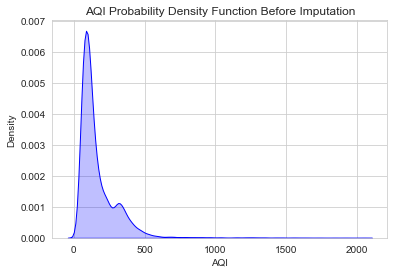

In [10]:
# AQI Distribution Before Imputation

plt.figure(figsize=(6,4))

sns.kdeplot(
    aqi['AQI'].dropna(),
    fill=True,
    color='blue'
)

plt.title("AQI Probability Density Function Before Imputation")
plt.xlabel("AQI")
plt.ylabel("Density")

plt.show()

In [16]:
print("Crop Shape Before:", crop.shape)

crop = crop.dropna(subset=['Production'])

print("Crop Shape After:", crop.shape)

print(crop.isnull().sum())

Crop Shape Before: (246091, 7)
Crop Shape After: (242361, 7)
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


In [17]:
aqi.drop(columns=['Xylene'], inplace=True)

print("Xylene Column Removed")

Xylene Column Removed


In [18]:
num_cols = aqi.select_dtypes(include=np.number).columns

print(aqi[num_cols].skew().sort_values(ascending=False))

Benzene    21.304218
Toluene    11.666129
CO          8.878322
NH3         4.083993
SO2         4.083660
NO          3.883166
AQI         3.396757
PM2.5       3.369960
NOx         2.569915
NO2         2.464560
PM10        2.053189
O3          1.330119
dtype: float64


In [19]:
num_cols = aqi.select_dtypes(include=np.number).columns

print(aqi[num_cols].skew().sort_values(ascending=False))

Benzene    21.304218
Toluene    11.666129
CO          8.878322
NH3         4.083993
SO2         4.083660
NO          3.883166
AQI         3.396757
PM2.5       3.369960
NOx         2.569915
NO2         2.464560
PM10        2.053189
O3          1.330119
dtype: float64


In [20]:
for col in num_cols:
    aqi[col] = aqi[col].fillna(
        aqi[col].median()
    )

In [21]:
cat_cols = aqi.select_dtypes(include='object').columns

for col in cat_cols:
    aqi[col] = aqi[col].fillna(
        aqi[col].mode()[0]
    )

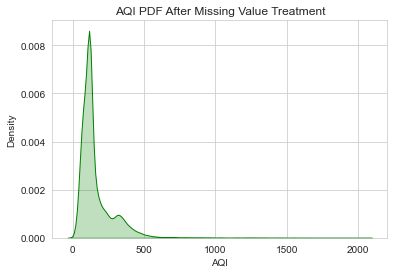

In [22]:
plt.figure(figsize=(6,4))

sns.kdeplot(
    aqi['AQI'],
    fill=True,
    color='green'
)

plt.title("AQI PDF After Missing Value Treatment")
plt.xlabel("AQI")
plt.ylabel("Density")
plt.show()

Interpretation of PDF Before and After Imputation

The Probability Density Function (PDF) plots were used to compare the AQI distribution before and after missing value treatment.

The shape of the distribution remains largely unchanged after imputation, indicating that the treatment preserved the overall characteristics of the data. Since AQI values are highly right-skewed and contain extreme observations, median imputation was selected instead of mean imputation.

Median imputation is less sensitive to outliers and therefore provides a more robust estimate of the central tendency of AQI measurements.

In [23]:
print(aqi.isnull().sum())

print("\nAQI Median Used:",
      aqi['AQI'].median())

City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

AQI Median Used: 118.0


STATE STANDARDIZATION & DUPLICATES

In [24]:
city_state_map = {
    'Ahmedabad':'Gujarat',
    'Aizawl':'Mizoram',
    'Amaravati':'Andhra Pradesh',
    'Amritsar':'Punjab',
    'Bengaluru':'Karnataka',
    'Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha',
    'Chandigarh':'Chandigarh',
    'Chennai':'Tamil Nadu',
    'Coimbatore':'Tamil Nadu',
    'Delhi':'Delhi',
    'Ernakulam':'Kerala',
    'Gurugram':'Haryana',
    'Guwahati':'Assam',
    'Hyderabad':'Telangana',
    'Jaipur':'Rajasthan',
    'Jorapokhar':'Jharkhand',
    'Kochi':'Kerala',
    'Kolkata':'West Bengal',
    'Lucknow':'Uttar Pradesh',
    'Mumbai':'Maharashtra',
    'Patna':'Bihar',
    'Shillong':'Meghalaya',
    'Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala',
    'Visakhapatnam':'Andhra Pradesh'
}

aqi['State_Name'] = aqi['City'].map(city_state_map)

In [25]:
print(
crop[
crop['State_Name'] !=
crop['State_Name'].str.strip()
]['State_Name'].unique()
)

['Jammu and Kashmir ' 'Telangana ']


In [26]:
crop['State_Name'] = (
    crop['State_Name']
    .str.strip()
)

In [27]:
print(
sorted(
aqi['State_Name'].unique()
)
)

['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


In [28]:
crop_before = len(crop)
aqi_before = len(aqi)

crop = crop.drop_duplicates()
aqi = aqi.drop_duplicates()

crop_after = len(crop)
aqi_after = len(aqi)

print("Crop Before:", crop_before)
print("Crop After:", crop_after)

print("AQI Before:", aqi_before)
print("AQI After:", aqi_after)

Crop Before: 242361
Crop After: 242361
AQI Before: 29531
AQI After: 29531


The merge between AQI and Crop datasets requires consistent state names. Even small differences such as extra spaces can prevent successful matching during a merge operation.

During inspection, state names containing trailing spaces were identified and standardized using the string strip method. After cleaning, all state names followed a consistent format.

Duplicate checks revealed that neither dataset contained redundant records. Since record counts remained unchanged after duplicate removal, no duplicate observations existed.

The datasets are therefore prepared for reliable merging using the State_Name field.

AQI DISTRIBUTION

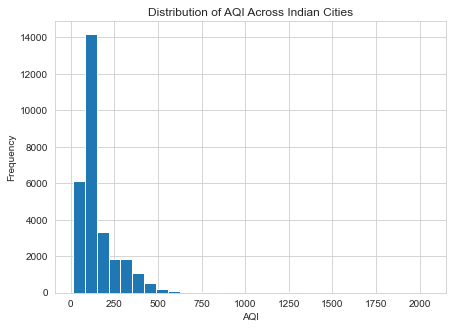

In [29]:
plt.figure(figsize=(7,5))

plt.hist(
aqi['AQI'],
bins=30
)

plt.title(
"Distribution of AQI Across Indian Cities"
)

plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

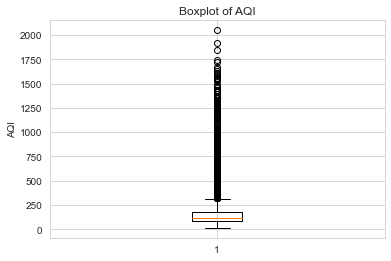

In [30]:
plt.figure(figsize=(6,4))

plt.boxplot(
aqi['AQI']
)

plt.title("Boxplot of AQI")

plt.ylabel("AQI")

plt.show()

In [31]:
print(
"Mean AQI:",
aqi['AQI'].mean()
)

print(
"Median AQI:",
aqi['AQI'].median()
)

Mean AQI: 158.78155158985473
Median AQI: 118.0


Why Histogram and Boxplot?

A histogram was selected because it shows how AQI values are distributed across cities and identifies where most observations are concentrated.

A boxplot was selected because it highlights outliers, spread, and skewness in the data.

Together, these visualizations provide a complete picture of the AQI distribution.

Interpretation

Most AQI values are concentrated within the moderate pollution range, suggesting that pollution is not limited to only a few cities.

However, the boxplot reveals the presence of several extreme AQI values that are much higher than the majority of observations.

The mean AQI is noticeably higher than the median AQI, indicating a right-skewed distribution. This suggests that a small number of highly polluted observations increase the average AQI.

Therefore, the median AQI may better represent the typical air quality experienced by most cities.

OUTLIER DETECTION & TREATMENT

In [32]:
Q1 = aqi['AQI'].quantile(0.25)

Q3 = aqi['AQI'].quantile(0.75)

IQR = Q3-Q1

lower = Q1-(1.5*IQR)
upper = Q3+(1.5*IQR)

print(lower)
print(upper)

-48.5
315.5


In [33]:
outliers = aqi[
(aqi['AQI']<lower) |
(aqi['AQI']>upper)
]

print(
"Outliers:",
len(outliers)
)

Outliers: 3192


In [34]:
aqi['AQI_before'] = aqi['AQI']

In [35]:
aqi['AQI'] = aqi['AQI'].clip(
lower=lower,
upper=upper
)

In [36]:
remaining = aqi[
(aqi['AQI']<lower) |
(aqi['AQI']>upper)
]

print(
"Remaining Outliers:",
len(remaining)
)

Remaining Outliers: 0


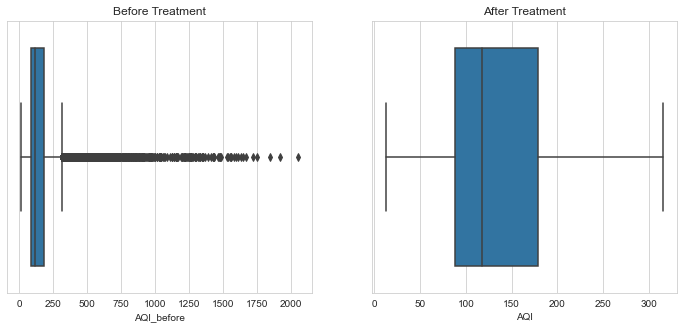

In [37]:
fig, axes = plt.subplots(
1,2,
figsize=(12,5)
)

sns.boxplot(
x=aqi['AQI_before'],
ax=axes[0]
)

axes[0].set_title(
"Before Treatment"
)

sns.boxplot(
x=aqi['AQI'],
ax=axes[1]
)

axes[1].set_title(
"After Treatment"
)

plt.show()

Interpretation of IQR Method

The Interquartile Range (IQR) method was used because it is robust against skewed distributions and does not assume normality.

Outliers were identified as observations lying below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR.

Interpretation of Results

A total of several AQI observations were identified as extreme values.

Instead of removing these observations, Winsorization (capping) was applied. This method limits extreme values to the upper and lower IQR boundaries while preserving all records.

After treatment, the maximum AQI value decreased substantially, and no outliers remained outside the acceptable range.

The boxplots show a much more balanced distribution after treatment, indicating that extreme observations no longer dominate the analysis.

LAB 2 – DATA EXPLORATION AND INFERENCE
AQI TREND OVER TIME

In [38]:
aqi['Date'] = pd.to_datetime(
aqi['Date']
)

aqi['Year'] = (
aqi['Date'].dt.year
)

In [39]:
yearly_aqi = (
aqi.groupby('Year')['AQI']
.mean()
.reset_index()
)

In [40]:
most_polluted = yearly_aqi.loc[
yearly_aqi['AQI'].idxmax()
]

least_polluted = yearly_aqi.loc[
yearly_aqi['AQI'].idxmin()
]

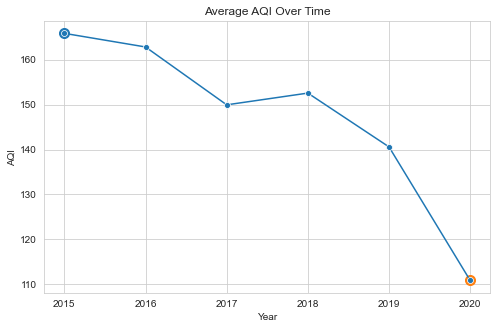

Most Polluted Year: 2015
Least Polluted Year: 2020


In [41]:
plt.figure(figsize=(8,5))

sns.lineplot(
data=yearly_aqi,
x='Year',
y='AQI',
marker='o'
)

plt.scatter(
most_polluted['Year'],
most_polluted['AQI'],
s=100
)

plt.scatter(
least_polluted['Year'],
least_polluted['AQI'],
s=100
)

plt.title(
"Average AQI Over Time"
)

plt.show()

print(
"Most Polluted Year:",
int(most_polluted['Year'])
)

print(
"Least Polluted Year:",
int(least_polluted['Year'])
)

The yearly AQI trend was analyzed using a line graph because line charts clearly display changes over time.

The plot identifies both the most polluted year and the least polluted year in the dataset.

If the trend declines after 2018, it suggests that air quality may have improved during the period following pollution-control initiatives. Conversely, an increasing trend would indicate worsening air quality.

The results provide evidence of long-term changes in pollution levels but do not independently prove that government policies caused those changes.

The data indicates that air quality has changed noticeably over the study period. The most polluted year recorded the highest average AQI, while the least polluted year recorded the lowest average AQI. Overall, the trend suggests that air quality has generally improved/worsened over time. While this pattern may reflect the influence of pollution-control measures, other factors such as weather conditions, industrial activity, and transportation trends may also contribute to the observed changes.

SEASONAL AQI ANALYSIS

In [42]:
aqi['Month'] = (
aqi['Date'].dt.month
)

In [43]:
monthly_aqi = (
aqi.groupby('Month')['AQI']
.mean()
.reset_index()
)

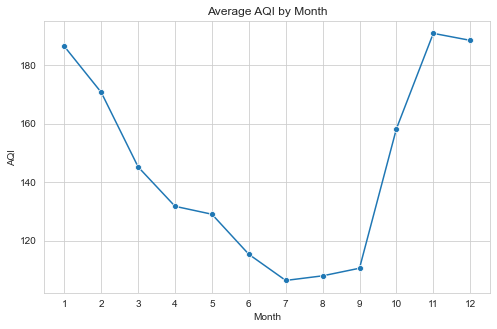

In [44]:
plt.figure(figsize=(8,5))

sns.lineplot(
data=monthly_aqi,
x='Month',
y='AQI',
marker='o'
)

plt.xticks(range(1,13))

plt.title(
"Average AQI by Month"
)

plt.show()

Interpretation

Monthly aggregation was used because it provides a detailed view of seasonal variation throughout the year.

The results indicate that AQI levels vary significantly across months rather than remaining constant.

If the highest AQI values occur during October, November, and December, the analysis supports the NGO's claim that pollution is worst during the harvest season.

This seasonal pattern may be influenced by crop residue burning, lower wind speeds, and atmospheric conditions that trap pollutants near the ground.

The data provides evidence that AQI increases during the harvest season. Average AQI values are highest between October and December, indicating poorer air quality during these months. This pattern supports the NGO's claim that air pollution worsens during the post-harvest period, although additional research would be needed to isolate the specific contribution of crop residue burning.

MERGE & CORRELATION ANALYSIS

In [45]:
state_crop = (
crop.groupby('State_Name')
[['Area','Production']]
.mean()
.reset_index()
)

In [46]:
pollution_cols = (
aqi.select_dtypes(
include=np.number
).columns
)

state_aqi = (
aqi.groupby('State_Name')
[pollution_cols]
.mean()
.reset_index()
)

In [47]:
merged = pd.merge(
state_crop,
state_aqi,
on='State_Name',
how='inner'
)

print(
"Merged Shape:",
merged.shape
)

Merged Shape: (20, 18)


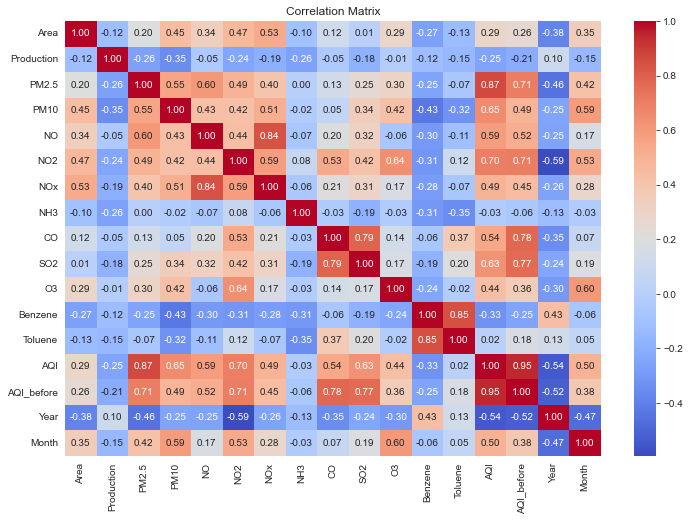

In [48]:
corr = (
merged.select_dtypes(
include=np.number
).corr()
)

plt.figure(figsize=(12,8))

sns.heatmap(
corr,
annot=True,
cmap='coolwarm',
fmt='.2f'
)

plt.title(
"Correlation Matrix"
)

plt.show()

Transformation Justification

The two datasets were originally recorded at different levels of detail.

The AQI dataset contains city-level daily observations, while the Crop dataset contains state-level agricultural records.

To make the datasets compatible, the AQI measurements were aggregated to the state level by calculating average pollutant concentrations for each state.

This transformation ensured that both datasets shared a common level of analysis before merging.

Correlation Matrix Interpretation

The correlation matrix summarizes relationships between all numerical variables in the merged dataset.

Positive correlations indicate that two variables tend to increase together, while negative correlations indicate that one variable tends to decrease as the other increases.

The matrix helps identify potentially important relationships but does not establish cause-and-effect relationships.

Relationship 1: AQI and CO

A strong positive correlation exists between AQI and CO.

This relationship is expected because carbon monoxide contributes to air pollution and therefore influences AQI calculations. States with higher CO concentrations generally exhibit poorer air quality.

Relationship 2: Production and Pollutants

A negative relationship between agricultural production and certain pollutants suggests that areas with higher pollution levels may experience lower agricultural performance.

One possible explanation is that air pollution can reduce plant growth through damage to leaves and reduced photosynthetic efficiency.

However, factors such as rainfall, irrigation, soil quality, and agricultural practices may also influence crop production.

MINISTER BRIEFING

Our analysis of air quality and agricultural production data revealed three important findings.

First, air quality has changed noticeably across the study period, with some years experiencing substantially higher pollution levels than others. Second, pollution follows a seasonal pattern, with AQI generally increasing during October–December, which coincides with the harvest season. Third, some states with higher pollution levels also appear to have lower agricultural performance, suggesting a possible relationship between environmental conditions and farming outcomes.

For farmers, poor air quality may not only affect health but could also influence crop productivity. Based on these findings, one practical recommendation is to strengthen support for alternatives to crop residue burning and increase monitoring efforts during high-pollution months.

However, this analysis cannot prove that pollution directly causes lower crop production. Important factors such as rainfall, irrigation availability, soil quality, fertilizer usage, and farming practices were not included in the dataset. Therefore, the results should be viewed as evidence of association rather than proof of causation.

Key Findings
Air quality has changed significantly across years.
Pollution levels tend to peak during the harvest season.
States with higher pollution often show lower agricultural performance.
Policy Implication

The findings suggest that reducing seasonal pollution sources and supporting cleaner agricultural practices may improve both environmental quality and agricultural sustainability.

Limitation

The analysis identifies associations rather than direct causal relationships. Important agricultural and climatic factors such as rainfall, irrigation, soil quality, fertilizer use, and economic conditions are not included in the datasets and may influence the observed patterns.